In [1]:
%matplotlib inline

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
from tensorflow.examples.tutorials.mnist import input_data
mnist = input_data.read_data_sets('MNIST_data', validation_size=0)

Instructions for updating:
Please use alternatives such as official/mnist/dataset.py from tensorflow/models.
Instructions for updating:
Please write your own downloading logic.
Instructions for updating:
Please use tf.data to implement this functionality.
Extracting MNIST_data/train-images-idx3-ubyte.gz
Instructions for updating:
Please use tf.data to implement this functionality.
Extracting MNIST_data/train-labels-idx1-ubyte.gz
Extracting MNIST_data/t10k-images-idx3-ubyte.gz
Extracting MNIST_data/t10k-labels-idx1-ubyte.gz
Instructions for updating:
Please use alternatives such as official/mnist/dataset.py from tensorflow/models.


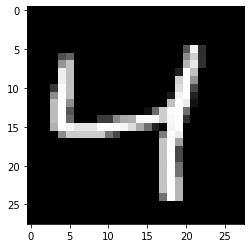

In [3]:
img = mnist.train.images[2]
plt.imshow(img.reshape((28, 28)), cmap='Greys_r')

In [4]:
learning_rate = 0.001
inputs_ = tf.placeholder(tf.float32, (None, 28, 28, 1), name='inputs')
targets_ = tf.placeholder(tf.float32, (None, 28, 28, 1), name='targets')

### Encoder
conv1 = tf.layers.conv2d(inputs_, 32, (5,5), padding='same', activation=tf.nn.relu)
maxpool1 = tf.layers.max_pooling2d(conv1, (2,2), (2,2), padding='same')
conv2 = tf.layers.conv2d(maxpool1, 16, (5,5), padding='same', activation=tf.nn.relu)
maxpool2 = tf.layers.max_pooling2d(conv2, (2,2), (2,2), padding='same')
conv3 = tf.layers.conv2d(maxpool2, 8, (5,5), padding='same', activation=tf.nn.relu)
encoded = tf.layers.max_pooling2d(conv3, (2,2), (2,2), padding='same')

### Decoder
upsample1 = tf.image.resize_nearest_neighbor(encoded, (7,7))
conv4 = tf.layers.conv2d(upsample1, 8, (5,5), padding='same', activation=tf.nn.relu)
upsample2 = tf.image.resize_nearest_neighbor(conv4, (14,14))
conv5 = tf.layers.conv2d(upsample2, 8, (5,5), padding='same', activation=tf.nn.relu)
upsample3 =  tf.image.resize_nearest_neighbor(conv5, (28,28))
conv6 = tf.layers.conv2d(upsample3, 8, (5,5), padding='same', activation=tf.nn.relu)

logits = tf.layers.conv2d(upsample3, 1, (5,5), padding='same')

decoded = tf.nn.sigmoid(logits, name='output')

loss = tf.nn.sigmoid_cross_entropy_with_logits(
    labels=targets_, logits=logits
)

cost = tf.reduce_mean(loss)
opt = tf.train.AdamOptimizer(learning_rate).minimize(cost)

Instructions for updating:
Use `tf.keras.layers.Conv2D` instead.
Instructions for updating:
Please use `layer.__call__` method instead.
Instructions for updating:
Use keras.layers.MaxPooling2D instead.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


In [5]:
sess = tf.Session()

In [6]:
epochs = 20
batch_size = 200
sess.run(tf.global_variables_initializer())
for e in range(epochs):
    for ii in range(mnist.train.num_examples//batch_size):
        batch = mnist.train.next_batch(batch_size)
        imgs = batch[0].reshape((-1, 28, 28, 1))
        batch_cost, _ = sess.run([cost, opt], feed_dict={inputs_: imgs,
                                                         targets_: imgs})

        print("Epoch: {}/{}...".format(e+1, epochs),
              "Training loss: {:.4f}".format(batch_cost))

Epoch: 1/20... Training loss: 0.6886
Epoch: 1/20... Training loss: 0.6762
Epoch: 1/20... Training loss: 0.6570
Epoch: 1/20... Training loss: 0.6293
Epoch: 1/20... Training loss: 0.5906
Epoch: 1/20... Training loss: 0.5541
Epoch: 1/20... Training loss: 0.5454
Epoch: 1/20... Training loss: 0.5403
Epoch: 1/20... Training loss: 0.5366
Epoch: 1/20... Training loss: 0.5204
Epoch: 1/20... Training loss: 0.4958
Epoch: 1/20... Training loss: 0.4844
Epoch: 1/20... Training loss: 0.4752
Epoch: 1/20... Training loss: 0.4692
Epoch: 1/20... Training loss: 0.4554
Epoch: 1/20... Training loss: 0.4459
Epoch: 1/20... Training loss: 0.4321
Epoch: 1/20... Training loss: 0.4253
Epoch: 1/20... Training loss: 0.4217
Epoch: 1/20... Training loss: 0.3953
Epoch: 1/20... Training loss: 0.3972
Epoch: 1/20... Training loss: 0.3709
Epoch: 1/20... Training loss: 0.3595
Epoch: 1/20... Training loss: 0.3478
Epoch: 1/20... Training loss: 0.3280
Epoch: 1/20... Training loss: 0.3264
Epoch: 1/20... Training loss: 0.3157
E

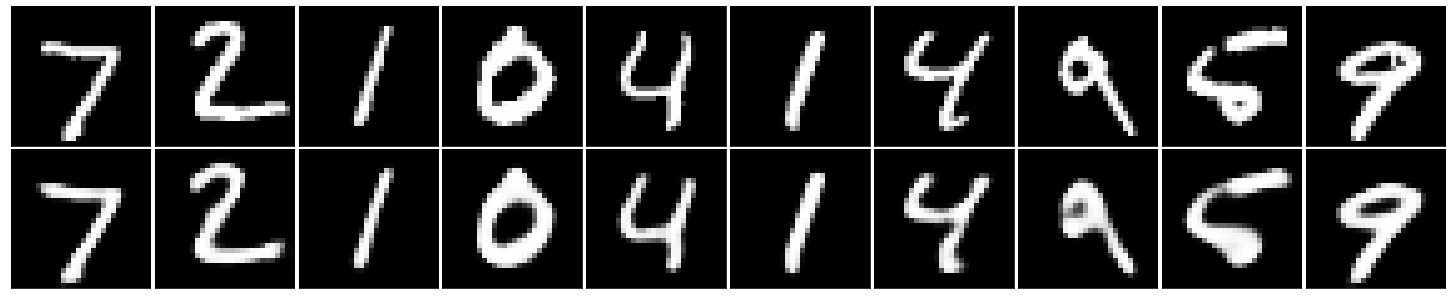

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=10, sharex=True, sharey=True, figsize=(20,4))
in_imgs = mnist.test.images[:10]
reconstructed = sess.run(decoded, feed_dict={inputs_: in_imgs.reshape((10, 28, 28, 1))})

for images, row in zip([in_imgs, reconstructed], axes):
    for img, ax in zip(images, row):
        ax.imshow(img.reshape((28, 28)), cmap='Greys_r')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)


fig.tight_layout(pad=0.1)

In [8]:
sess.close()

## Denoising

In [10]:
learning_rate = 0.001
inputs_ = tf.placeholder(tf.float32, (None, 28, 28, 1), name='inputs')
targets_ = tf.placeholder(tf.float32, (None, 28, 28, 1), name='targets')

### Encoder
conv1 = tf.layers.conv2d(inputs_, 32, (5,5), padding='same', activation=tf.nn.relu)
maxpool1 = tf.layers.max_pooling2d(conv1, (2,2), (2,2), padding='same')
conv2 = tf.layers.conv2d(maxpool1, 32, (5,5), padding='same', activation=tf.nn.relu)
maxpool2 = tf.layers.max_pooling2d(conv2, (2,2), (2,2), padding='same')
conv3 = tf.layers.conv2d(maxpool2, 16, (5,5), padding='same', activation=tf.nn.relu)
encoded = tf.layers.max_pooling2d(conv2, (2,2), (2,2), padding='same')

### Decoder
upsample1 = tf.image.resize_nearest_neighbor(encoded, (7,7))
conv4 = tf.layers.conv2d(upsample1, 16, (5,5), padding='same', activation=tf.nn.relu)
upsample2 = tf.image.resize_nearest_neighbor(conv4, (14,14))
conv5 = tf.layers.conv2d(upsample2, 32, (5,5), padding='same', activation=tf.nn.relu)
upsample3 = tf.image.resize_nearest_neighbor(conv5, (28,28))
conv6 = tf.layers.conv2d(upsample3, 32, (5,5), padding='same', activation=tf.nn.relu)

logits = tf.layers.conv2d(conv6, 1, (5,5), padding='same')

decoded = tf.nn.sigmoid(logits, name='output')

loss = tf.nn.sigmoid_cross_entropy_with_logits(
    labels=targets_, logits=logits
)

cost = tf.reduce_mean(loss)
opt = tf.train.AdamOptimizer(learning_rate).minimize(cost)

In [11]:
sess = tf.Session()

In [12]:
epochs = 100
batch_size = 200
noise_factor = 0.5
sess.run(tf.global_variables_initializer())
for e in range(epochs):
    for ii in range(mnist.train.num_examples//batch_size):
        batch = mnist.train.next_batch(batch_size)
        imgs = batch[0].reshape((-1, 28, 28, 1))
        
        # Add random noise to the input images
        noisy_imgs = imgs + noise_factor * np.random.randn(*imgs.shape)
        noisy_imgs = np.clip(noisy_imgs, 0., 1.)
        
        # Noisy images as inputs, original images as targets
        batch_cost, _ = sess.run([cost, opt], feed_dict={inputs_: noisy_imgs,
                                                         targets_: imgs})

        print("Epoch: {}/{}...".format(e+1, epochs),
              "Training loss: {:.4f}".format(batch_cost))

Epoch: 1/100... Training loss: 0.6846
Epoch: 1/100... Training loss: 0.6215
Epoch: 1/100... Training loss: 0.5240
Epoch: 1/100... Training loss: 0.6283
Epoch: 1/100... Training loss: 0.5287
Epoch: 1/100... Training loss: 0.5008
Epoch: 1/100... Training loss: 0.5142
Epoch: 1/100... Training loss: 0.5172
Epoch: 1/100... Training loss: 0.4986
Epoch: 1/100... Training loss: 0.4747
Epoch: 1/100... Training loss: 0.4500
Epoch: 1/100... Training loss: 0.4382
Epoch: 1/100... Training loss: 0.4452
Epoch: 1/100... Training loss: 0.4037
Epoch: 1/100... Training loss: 0.3709
Epoch: 1/100... Training loss: 0.3583
Epoch: 1/100... Training loss: 0.3326
Epoch: 1/100... Training loss: 0.3160
Epoch: 1/100... Training loss: 0.3171
Epoch: 1/100... Training loss: 0.3039
Epoch: 1/100... Training loss: 0.2858
Epoch: 1/100... Training loss: 0.2776
Epoch: 1/100... Training loss: 0.2761
Epoch: 1/100... Training loss: 0.2750
Epoch: 1/100... Training loss: 0.2701
Epoch: 1/100... Training loss: 0.2741
Epoch: 1/100

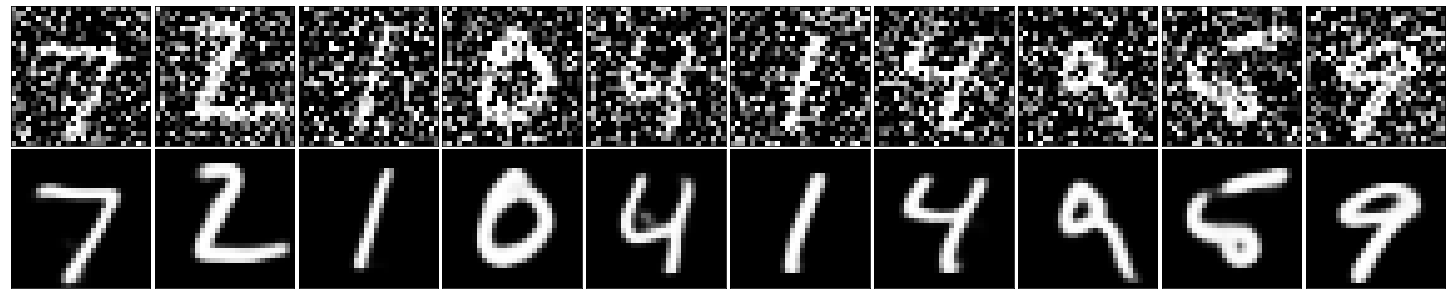

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=10, sharex=True, sharey=True, figsize=(20,4))
in_imgs = mnist.test.images[:10]
noisy_imgs = in_imgs + noise_factor * np.random.randn(*in_imgs.shape)
noisy_imgs = np.clip(noisy_imgs, 0., 1.)

reconstructed = sess.run(decoded, feed_dict={inputs_: noisy_imgs.reshape((10, 28, 28, 1))})

for images, row in zip([noisy_imgs, reconstructed], axes):
    for img, ax in zip(images, row):
        ax.imshow(img.reshape((28, 28)), cmap='Greys_r')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

fig.tight_layout(pad=0.1)